### DATA INGESTION 

**INITIALIZE SPARKNLP AND OTHER PACKAGES**

In [1]:
# Standard Library Imports
# ----------------------------
import os
from itertools import chain

# Numerical & Visualization
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Spark & Spark NLP
# ----------------------------
import sparknlp
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, expr, desc, create_map, lit, udf
from pyspark.sql.types import FloatType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    CountVectorizer,
    IDF,
    NGram,
    VectorAssembler,
    StringIndexer,
    StringIndexerModel
)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from sparknlp.base import DocumentAssembler, Finisher
from sparknlp.annotator import (
    Tokenizer,
    Normalizer,
    Stemmer,
    StopWordsCleaner,
    BertEmbeddings,
    BertSentenceEmbeddings,
    SentenceEmbeddings,
    ClassifierDLApproach
)


# Scikit-learn Metrics
# ----------------------------
from sklearn.metrics import classification_report, confusion_matrix


# Environment Configuration
# ----------------------------
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"  # ensures Spark binds to localhost

In [2]:
import mlflow
import mlflow.spark
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Point MLflow to your local folder (mlruns is one level up from notebooks/)
mlflow.set_tracking_uri("file:../mlruns")

# 2. Create or reuse an experiment called "legal_doc_classification"
mlflow.set_experiment("CONTRACT_NLP_CLASSIFICATION")


<Experiment: artifact_location='file:///Users/jefferyjapheth/Documents/dev/devsuite/project/contract_nlp/notebooks/../mlruns/311994224632715344', creation_time=1756997161474, experiment_id='311994224632715344', last_update_time=1756997161474, lifecycle_stage='active', name='CONTRACT_NLP_CLASSIFICATION', tags={}>

In [3]:
# Use the direct JAR approach for Apple Silicon (SparkNLP 6.1.2)
spark = (SparkSession.builder
    .appName("Text_Classification_NLP")
    .master("local[8]")
    .config("spark.driver.memory", "12g")
    .config("spark.executor.memory", "12g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    # Use direct JAR for Apple Silicon - version 6.1.2
    .config("spark.jars", "../misc/spark-nlp-silicon-assembly-6.1.2.jar")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "2000M")
    # Apple Silicon optimizations
    .config("spark.driver.extraJavaOptions", "-XX:+UseG1GC")
    .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC")
     # Tell Spark NLP where to cache / look for pretrained models
    .config("spark.jsl.settings.pretrained.cache_folder", "./models")
    .getOrCreate()
)

# Check if SparkNLP is loaded
print("Spark version:", spark.version)
print("SparkNLP version:", sparknlp.version())

# Test that it's working
from sparknlp.pretrained import PretrainedPipeline
print("SparkNLP initialized successfully with Apple Silicon support")

25/09/04 15:01:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version: 3.5.6
SparkNLP version: 6.1.2
SparkNLP initialized successfully with Apple Silicon support


**LOAD CLEAN MCC DATASET**

In [4]:
# Load the cleaned contract dataset
df = spark.read.parquet("../data/processed/mcc_contracts_full")

print(f"Dataset loaded! Total records: {df.count():,}")
df.printSchema()

Dataset loaded! Total records: 396,532
root
 |-- company_name: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- description: string (nullable = true)
 |-- amend: string (nullable = true)
 |-- restate: string (nullable = true)
 |-- joinder: double (nullable = true)
 |-- termination: integer (nullable = true)
 |-- agreement_type: string (nullable = true)
 |-- data_split: integer (nullable = true)
 |-- label_count: long (nullable = true)
 |-- type_label: string (nullable = true)



### DATA EXPLORATION TO SHOW CLASS DISTRIBUTION/ DATA SPLITS AND SAMPLE RECORDS

In [5]:
#Data Exploration and Basic Stats

# Show class distribution
print("Class Distribution:")
df.groupBy("agreement_type", "type_label").count().orderBy(desc("count")).show()

# Check data splits
print("Data Split Distribution:")
df.groupBy("data_split").count().show()

# Sample records to see the text
print("Sample Records:")
df.select("contract", "description", "agreement_type").limit(3).show(truncate=False)

Class Distribution:


+---------------+----------+------+
| agreement_type|type_label| count|
+---------------+----------+------+
|     employment|   LABEL_1|144783|
|       security|   LABEL_0|102425|
|    purchase&ma|   LABEL_4| 56612|
|services&supply|   LABEL_3| 32168|
|    shareholder|   LABEL_5| 20002|
|          other|   LABEL_6| 18203|
|          lease|   LABEL_2| 11879|
|             na|   LABEL_7| 10460|
+---------------+----------+------+

Data Split Distribution:
+----------+-----+
|data_split|count|
+----------+-----+
|         1|79007|
|         2|79373|
|         3|79461|
|         4|79260|
|         5|79431|
+----------+-----+

Sample Records:
+---------------------------------------------------------------------+------------------------------------------+--------------+
|contract                                                             |description                               |agreement_type|
+---------------------------------------------------------------------+-----------------------

**DOWNSAMPLING AND COMPUTING CLASS WEIGHTS TO TACKLE CLASS IMBALANCE**

In [6]:
#  Identify majority classes to downsample
# ----------------------------
majority_classes = ["employment", "security"]

# Define downsample fractions (reduce to 50% of their current counts)
downsample_fractions = {
    "employment": 0.5,
    "security": 0.5
}

# For classes not in majority_classes, keep all
all_labels = [row["agreement_type"] for row in df.select("agreement_type").distinct().collect()]
for label in all_labels:
    if label not in majority_classes:
        downsample_fractions[label] = 1.0


#  Downsample dataset
# ----------------------------
df_downsampled = df.sampleBy("agreement_type", fractions=downsample_fractions, seed=42)
print(f"Original count: {df.count():,}, After downsampling: {df_downsampled.count():,}")

# Optional: check new class distribution
print("Downsampled Class Distribution:")
df_downsampled.groupBy("agreement_type", "type_label").count().orderBy(desc("count")).show()

Original count: 396,532, After downsampling: 273,127
Downsampled Class Distribution:
+---------------+----------+-----+
| agreement_type|type_label|count|
+---------------+----------+-----+
|     employment|   LABEL_1|72546|
|    purchase&ma|   LABEL_4|56612|
|       security|   LABEL_0|51257|
|services&supply|   LABEL_3|32168|
|    shareholder|   LABEL_5|20002|
|          other|   LABEL_6|18203|
|          lease|   LABEL_2|11879|
|             na|   LABEL_7|10460|
+---------------+----------+-----+



In [7]:
# Compute counts per class
label_counts = df_downsampled.groupBy("type_label").count().collect()
total_count = df_downsampled.count()
num_classes = len(label_counts)

# Compute class weights = total_count / (num_classes * count)
class_weights = {row['type_label']: total_count / (num_classes * row['count']) for row in label_counts}

# UDF to assign weight to each row
def get_weight(label):
    return float(class_weights[label])

weight_udf = udf(get_weight, FloatType())
df_weighted = df_downsampled.withColumn("class_weight", weight_udf(F.col("type_label")))

df = df_weighted
# Quick check
df.groupBy("type_label").agg(F.avg("class_weight")).show()

+----------+-------------------+
|type_label|  avg(class_weight)|
+----------+-------------------+
|   LABEL_0|  0.666072428226471|
|   LABEL_4| 0.6030678153038025|
|   LABEL_1|0.47061002254486084|
|   LABEL_5| 1.7068730592727661|
|   LABEL_3| 1.0613303184509277|
|   LABEL_7|  3.263946056365967|
|   LABEL_2| 2.8740530014038086|
|   LABEL_6|  1.875563144683838|
+----------+-------------------+



## Text preprocessing in Spark NLP and using ML algorithms from Spark ML

### NLP PIPELINE FOR CLASSICAL ML MODELS

In [8]:
# Document
document_assembler = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

# Tokenize
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("tokens")

# Normalize
normalizer = Normalizer() \
    .setInputCols(["tokens"]) \
    .setOutputCol("normalized_tokens") \
    .setLowercase(True)

# Stemmer (better for TF-IDF classification)
stemmer = Stemmer() \
    .setInputCols(["normalized_tokens"]) \
    .setOutputCol("stem_tokens")

# Stopwords
stopwords_cleaner = StopWordsCleaner() \
    .setInputCols(["stem_tokens"]) \
    .setOutputCol("clean_tokens") \
    .setCaseSensitive(False)

# Finisher
finisher = Finisher() \
    .setInputCols(["clean_tokens"]) \
    .setOutputCols(["finished_tokens"]) \
    .setOutputAsArray(True)

pipeline = Pipeline(stages=[
    document_assembler,
    tokenizer,
    normalizer,
    stemmer,
    stopwords_cleaner,
    finisher
])

**FIT AND TRANSFORM RAW DATASET WITH NLP**

In [9]:
classical_nlp = pipeline.fit(df)
df_tokens = classical_nlp.transform(df)

df_tokens = df_tokens.withColumn(
    "finished_tokens",
    expr("filter(finished_tokens, x -> length(x) > 2)")
)

# Check results
df_tokens.select("type_label","agreement_type", "finished_tokens").show(20, truncate=False)

+----------+--------------+----------------------------------------------------------------------+
|type_label|agreement_type|finished_tokens                                                       |
+----------+--------------+----------------------------------------------------------------------+
|LABEL_0   |security      |[amend, restat, guaranti]                                             |
|LABEL_0   |security      |[promissori, note, curcurp, camera]                                   |
|LABEL_0   |security      |[pledg, agreem, michael, thobin, iii]                                 |
|LABEL_0   |security      |[secur, convert, note]                                                |
|LABEL_0   |security      |[first, amend, waiver, credit, agreem]                                |
|LABEL_0   |security      |[second, amend, financ, agreem]                                       |
|LABEL_0   |security      |[amend, second, amend, restat]                                        |
|LABEL_0  

#### FEATURE PIPELINE

**N-GRAMS, COUNT VECTORIZER, TF-IDF Feature Extraction**

In [10]:
#  Create bigrams
bigram = NGram(n=2, inputCol="finished_tokens", outputCol="bigrams")

#  CountVectorizer for unigrams
cv_unigram = CountVectorizer(
    inputCol="finished_tokens", 
    outputCol="cv_unigram", 
    vocabSize=10000, 
    minDF=2
)

#  CountVectorizer for bigrams
cv_bigram = CountVectorizer(
    inputCol="bigrams", 
    outputCol="cv_bigram", 
    vocabSize=20000, 
    minDF=2
)

#  Combine features into single sparse vector
assembler = VectorAssembler(
    inputCols=["cv_unigram", "cv_bigram"], 
    outputCol="raw_features"
)

#  Apply IDF
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

#  label indexer including all labels
fixed_labels = ["LABEL_0", "LABEL_1", "LABEL_2", "LABEL_3", "LABEL_4", "LABEL_5", "LABEL_6", "LABEL_7"]

label_indexer = StringIndexerModel.from_labels(
    labels=fixed_labels,
    inputCol="type_label",
    outputCol="label_indexed"
)

#  Full pipeline
feature_pipeline = Pipeline(stages=[
    bigram,
    cv_unigram,
    cv_bigram,
    assembler,
    idf,
    label_indexer
])

#  Fit and transform
feature_model = feature_pipeline.fit(df_tokens)
feature_df = feature_model.transform(df_tokens)

#  Check results
feature_df.select(
    "contract",
    "agreement_type",
    "tfidf_features",
    "label_indexed"
).show(20, truncate=False)


25/09/04 15:01:33 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/09/04 15:01:43 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


+-------------------------------------------------------------------------------+--------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+
|contract                                                                       |agreement_type|tfidf_features                                                                                                                                                                                                                                                                                                                            |label_indexed|
+-------------------------------------------------------------------------------+--------------+--------------------

In [11]:
# Cache tokenized data for performance
feature_df = feature_df.cache()  

#confirm custom label mappings
feature_df.groupBy("agreement_type","label_indexed","type_label").count().orderBy(desc("count")).show() # Triggers caching

25/09/04 15:01:44 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:54 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


+---------------+-------------+----------+-----+
| agreement_type|label_indexed|type_label|count|
+---------------+-------------+----------+-----+
|     employment|          1.0|   LABEL_1|72546|
|    purchase&ma|          4.0|   LABEL_4|56612|
|       security|          0.0|   LABEL_0|51257|
|services&supply|          3.0|   LABEL_3|32168|
|    shareholder|          5.0|   LABEL_5|20002|
|          other|          6.0|   LABEL_6|18203|
|          lease|          2.0|   LABEL_2|11879|
|             na|          7.0|   LABEL_7|10460|
+---------------+-------------+----------+-----+



25/09/04 15:01:54 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


**PREPARE TRAIN/ VAL/ TEST SPLITS FOR MODEL**

In [12]:
from pyspark.sql import functions as F

# Get list of unique labels
labels = [row['type_label'] for row in feature_df.select("type_label").distinct().collect()]

# Define fraction ratios
train_frac = 0.7
val_frac = 0.15
test_frac = 0.15

# Sample train set stratified by type_label
fractions_train = {label: train_frac for label in labels}
train_df = feature_df.sampleBy("type_label", fractions=fractions_train, seed=42)

# Remaining after train
remaining_df = feature_df.subtract(train_df)

# Sample validation set from remaining stratified by type_label
fractions_val = {label: val_frac / (val_frac + test_frac) for label in labels}  # proportion of remaining
val_df = remaining_df.sampleBy("type_label", fractions=fractions_val, seed=42)

# Remaining is test set
test_df = remaining_df.subtract(val_df)

# Cache for performance
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

# Inspect counts
print(f"Train: {train_df.count():,}")
print(f"Validation: {val_df.count():,}")
print(f"Test: {test_df.count():,}")

# Inspect class distribution
for df, name in zip([train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    print(f"\n{name} class distribution:")
    df.groupBy("agreement_type").count().orderBy("agreement_type").show(truncate=False)


25/09/04 15:01:54 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:54 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:55 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/09/04 15:01:55 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:55 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


Train: 191,668


25/09/04 15:01:55 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:55 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:56 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/04 15:01:58 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:01:58 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB


Validation: 40,823


25/09/04 15:01:58 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:59 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:01:59 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:01:59 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/04 15:02:00 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:01 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:01 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


...

25/09/04 15:02:02 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |10811|
|lease          |1728 |
|na             |1626 |
|other          |2659 |
|purchase&ma    |8505 |
|security       |7735 |
|services&supply|4747 |
|shareholder    |3012 |
+---------------+-----+


Test class distribution:


25/09/04 15:02:02 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


+---------------+-----+
|agreement_type |count|
+---------------+-----+
|employment     |10894|
|lease          |1802 |
|na             |1558 |
|other          |2748 |
|purchase&ma    |8329 |
|security       |7598 |
|services&supply|4755 |
|shareholder    |2951 |
+---------------+-----+



25/09/04 15:02:03 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


### CLASSICAL ML MODELS

**DEFINE LOGISTIC REGRESSION**

In [13]:
from pyspark.sql.functions import lit, col, create_map, when, array_max
from pyspark.ml.functions import vector_to_array
from itertools import chain

# --- Map class weights
class_weight_map = create_map(
    *chain.from_iterable([(lit(k), lit(float(v))) for k, v in class_weights.items()])
)

# Add class_weight column to training set
train_df = train_df.withColumn("class_weight", class_weight_map[col("type_label")])

# --- Define Logistic Regression with class weights
lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label_indexed",
    weightCol="class_weight",
    maxIter=180,
    regParam=0.01,
    elasticNetParam=0.1
)

# --- Train model
lr_model = lr.fit(train_df)

# --- Save trained model
lr_model.write().overwrite().save("../finetuned_models/lr")

# --- Validate
val_predictions = lr_model.transform(val_df)


25/09/04 15:02:03 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:03 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/09/04 15:02:04 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:04 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:05 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:05 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:05 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:05 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:06 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:06 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:06 WARN DAGSchedul

**SAVING MODELS FOR FASTAPI**

In [14]:
import json
import os
from pyspark.ml import PipelineModel
from pyspark.ml.classification import LogisticRegressionModel

# Base path (relative to notebooks) ---
BASE_DIR = "../app"
MODEL_DIR = os.path.join(BASE_DIR, "models")

#  Define paths for saving each model type ---
CLASSICAL_NLP_PATH = os.path.join(MODEL_DIR, "classical_nlp_pipeline")   # Pipeline
FEATURE_PIPELINE_PATH = os.path.join(MODEL_DIR, "feature_pipeline")      # Pipeline
LR_MODEL_PATH = os.path.join(MODEL_DIR, "lr_model")                       # Single model
LABEL_MAPPING_PATH = os.path.join(MODEL_DIR, "label_mappings.json")      # JSON

# Ensure model folder exists ---
os.makedirs(MODEL_DIR, exist_ok=True)

#  Save pipelines using PipelineModel.write() ---
classical_nlp.write().overwrite().save(CLASSICAL_NLP_PATH)
print(f"Classical NLP pipeline saved at {CLASSICAL_NLP_PATH}")

feature_model.write().overwrite().save(FEATURE_PIPELINE_PATH)
print(f"Feature pipeline saved at {FEATURE_PIPELINE_PATH}")

#  Save Logistic Regression model  ---
lr_model.write().overwrite().save(LR_MODEL_PATH)
print(f"Logistic Regression model saved at {LR_MODEL_PATH}")

#  Save label mappings as JSON ---
label_mappings = {
    "0": "security",
    "1": "employment",
    "2": "lease",
    "3": "services&supply",
    "4": "purchase&ma",
    "5": "shareholder",
    "6": "other",
    "7": "na"
}

with open(LABEL_MAPPING_PATH, "w") as f:
    json.dump(label_mappings, f)
print(f"Label mappings saved at {LABEL_MAPPING_PATH}")

# --- 4. Load models correctly 
classical_nlp_loaded = PipelineModel.load(CLASSICAL_NLP_PATH)
feature_pipeline_loaded = PipelineModel.load(FEATURE_PIPELINE_PATH)
lr_model_loaded = LogisticRegressionModel.load(LR_MODEL_PATH)

# --- 5. Load label mappings ---
with open(LABEL_MAPPING_PATH, "r") as f:
    label_mappings_loaded = json.load(f)

print("All models and label mappings loaded successfully")


Classical NLP pipeline saved at ../app/models/classical_nlp_pipeline
Feature pipeline saved at ../app/models/feature_pipeline
Logistic Regression model saved at ../app/models/lr_model
Label mappings saved at ../app/models/label_mappings.json
All models and label mappings loaded successfully


In [15]:
# --- Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="label_indexed",
    predictionCol="prediction",
    metricName="f1"
)
val_f1 = evaluator.evaluate(val_predictions)
print(f"Validation F1: {val_f1:.4f}")

25/09/04 15:02:32 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


Validation F1: 0.8733


### GRID SEARCH FOR DYNAMIC FALLBACK

In [16]:
# Candidate thresholds for search
conf_thresholds_ambig = [0.5, 0.6, 0.7]
conf_thresholds_others = [0.2, 0.3, 0.4]
margins_ambig = [0.1, 0.15, 0.2]
margins_others = [0.05, 0.1]

In [17]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F
from sklearn.metrics import f1_score

def apply_fallback(pred_df, conf_a, conf_o, margin_a, margin_o, fallback_label=7, ambig_classes=[0,3,4,6]):
    df = pred_df.withColumn("prob_array", vector_to_array("probability"))
    df = df.withColumn("sorted_probs", F.array_sort("prob_array"))
    df = df.withColumn("top1_prob", F.element_at("sorted_probs", -1))
    df = df.withColumn("top2_prob", F.element_at("sorted_probs", -2))
    df = df.withColumn("margin", F.col("top1_prob") - F.col("top2_prob"))
    
    df = df.withColumn(
        "final_prediction",
        F.when(
            (
                (F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_a) | (F.col("margin") < margin_a))
            ) |
            (
                (~F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_o) | (F.col("margin") < margin_o))
            ),
            F.lit(fallback_label)
        ).otherwise(F.col("prediction"))
    )
    return df

In [18]:
results = []

# Collect ground truth once
y_true = val_predictions.select("label_indexed").toPandas()["label_indexed"]

for ca in conf_thresholds_ambig:
    for co in conf_thresholds_others:
        for ma in margins_ambig:
            for mo in margins_others:
                df_out = apply_fallback(val_predictions, ca, co, ma, mo)
                y_pred = df_out.select("final_prediction").toPandas()["final_prediction"]
                f1 = f1_score(y_true, y_pred, average="weighted")
                
                results.append({
                    "conf_ambig": ca,
                    "conf_other": co,
                    "margin_ambig": ma,
                    "margin_other": mo,
                    "f1": f1
                })


25/09/04 15:02:33 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:34 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:34 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:35 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:35 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:36 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:36 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:37 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:37 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:38 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:38 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:02:39 WARN DAGScheduler: Broadcasting larg

In [19]:
import pandas as pd
results_df = pd.DataFrame(results)
best = results_df.sort_values("f1", ascending=False).head(10)
print(best)

    conf_ambig  conf_other  margin_ambig  margin_other        f1
0          0.5         0.2          0.10          0.05  0.861005
6          0.5         0.3          0.10          0.05  0.860795
1          0.5         0.2          0.10          0.10  0.860488
7          0.5         0.3          0.10          0.10  0.860470
12         0.5         0.4          0.10          0.05  0.859975
2          0.5         0.2          0.15          0.05  0.859945
13         0.5         0.4          0.10          0.10  0.859743
8          0.5         0.3          0.15          0.05  0.859740
3          0.5         0.2          0.15          0.10  0.859433
9          0.5         0.3          0.15          0.10  0.859416


In [20]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

# Parameters (best found)
FALLBACK_LABEL = 7
CONF_THRESHOLD_AMBIG = 0.5   # best floor for ambiguous classes
CONF_THRESHOLD_OTHERS = 0.2  # best floor for strong classes
MARGIN_AMBIG = 0.10          # best margin for ambiguous classes
MARGIN_OTHERS = 0.05         # best margin for other classes
AMBIG_CLASSES = [0, 3, 4, 6]

# Convert prob vector to array
val_predictions = val_predictions.withColumn(
    "prob_array", vector_to_array("probability")
)

# Extract top probs
val_predictions = val_predictions.withColumn(
    "sorted_probs", F.array_sort(F.col("prob_array"))
).withColumn(
    "top1_prob", F.element_at("sorted_probs", -1)
).withColumn(
    "top2_prob", F.element_at("sorted_probs", -2)
).withColumn(
    "margin", F.col("top1_prob") - F.col("top2_prob")
)

# Apply dynamic fallback with best params
val_predictions = val_predictions.withColumn(
    "final_prediction",
    F.when(
        (
            # ambiguous classes → stricter threshold + margin
            (F.col("prediction").isin(AMBIG_CLASSES)) &
            (
                (F.col("top1_prob") < CONF_THRESHOLD_AMBIG) |
                (F.col("margin") < MARGIN_AMBIG)
            )
        )
        |
        (
            # other classes → looser threshold + margin
            (~F.col("prediction").isin(AMBIG_CLASSES)) &
            (
                (F.col("top1_prob") < CONF_THRESHOLD_OTHERS) |
                (F.col("margin") < MARGIN_OTHERS)
            )
        ),
        F.lit(FALLBACK_LABEL)
    ).otherwise(F.col("prediction"))
)


### MLFLOW

In [ ]:
import mlflow
import mlflow.spark
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from pyspark.ml.classification import LogisticRegression

# -------------------------
# Helper: log dataset stats
# -------------------------
def log_dataset_stats(train_df, val_df):
    # Sizes
    mlflow.log_param("train_size", train_df.count())
    mlflow.log_param("val_size", val_df.count())

    # Class distribution (train + val)
    train_dist = train_df.groupBy("label_indexed").count().toPandas()
    val_dist = val_df.groupBy("label_indexed").count().toPandas()

    train_dist.to_csv("train_distribution.csv", index=False)
    val_dist.to_csv("val_distribution.csv", index=False)

    mlflow.log_artifact("train_distribution.csv", artifact_path="data_stats")
    mlflow.log_artifact("val_distribution.csv", artifact_path="data_stats")

    # Imbalance ratio (train)
    imbalance_ratio = train_dist["count"].max() / train_dist["count"].min()
    mlflow.log_metric("imbalance_ratio_train", imbalance_ratio)


# -------------------------
# 1. Baseline TFIDF + LR
# -------------------------
def run_experiment_tfidf_lr_baseline(train_df, val_df, class_weights, run_name="TFIDF+LR Baseline"):
    with mlflow.start_run(run_name=run_name):
        # Log dataset info
        log_dataset_stats(train_df, val_df)

        # Logistic Regression
        lr = LogisticRegression(
            featuresCol="tfidf_features",
            labelCol="label_indexed",
            weightCol="class_weight",
            maxIter=180,
            regParam=0.01,
            elasticNetParam=0.1
        )
        lr_model = lr.fit(train_df)
        mlflow.spark.log_model(lr_model, artifact_path="lr_model")

        # Predictions
        val_predictions = lr_model.transform(val_df)
        y_true = val_predictions.select("label_indexed").toPandas()["label_indexed"]
        y_pred = val_predictions.select("prediction").toPandas()["prediction"]

        # Metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        report = classification_report(y_true, y_pred, output_dict=True)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_weighted", f1)

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report_baseline.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix_baseline.csv"
        cm_df.to_csv(cm_csv_path, index=False)
        mlflow.log_artifact(cm_csv_path, artifact_path="evaluation")

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix (Baseline)")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        cm_png_path = "confusion_matrix_baseline.png"
        plt.savefig(cm_png_path)
        plt.close()
        mlflow.log_artifact(cm_png_path, artifact_path="evaluation")

        print(f" Logged {run_name} with F1={f1:.4f}, Acc={acc:.4f}")


# -------------------------
# 2. TFIDF + LR + Fallback
# -------------------------
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

def apply_fallback(pred_df, conf_a, conf_o, margin_a, margin_o,
                   fallback_label=7, ambig_classes=[0,3,4,6]):
    df = pred_df.withColumn("prob_array", vector_to_array("probability"))
    df = df.withColumn("sorted_probs", F.array_sort("prob_array"))
    df = df.withColumn("top1_prob", F.element_at("sorted_probs", -1))
    df = df.withColumn("top2_prob", F.element_at("sorted_probs", -2))
    df = df.withColumn("margin", F.col("top1_prob") - F.col("top2_prob"))
    
    df = df.withColumn(
        "final_prediction",
        F.when(
            (
                (F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_a) | (F.col("margin") < margin_a))
            ) |
            (
                (~F.col("prediction").isin(ambig_classes)) &
                ((F.col("top1_prob") < conf_o) | (F.col("margin") < margin_o))
            ),
            F.lit(fallback_label)
        ).otherwise(F.col("prediction"))
    )
    return df

def run_experiment_tfidf_lr_fallback(
    train_df, val_df, class_weights,
    conf_thresholds_ambig=[0.5, 0.6, 0.7],
    conf_thresholds_others=[0.2, 0.3, 0.4],
    margins_ambig=[0.1, 0.15, 0.2],
    margins_others=[0.05, 0.1],
    fallback_label=7,
    ambig_classes=[0,3,4,6],
    run_name="TFIDF+LR+Fallback"
):
    with mlflow.start_run(run_name=run_name):
        # Log dataset info
        log_dataset_stats(train_df, val_df)

        # Logistic Regression
        lr = LogisticRegression(
            featuresCol="tfidf_features",
            labelCol="label_indexed",
            weightCol="class_weight",
            maxIter=180,
            regParam=0.01,
            elasticNetParam=0.1
        )
        lr_model = lr.fit(train_df)
        mlflow.spark.log_model(lr_model, "lr_model")

        # Predictions
        val_predictions = lr_model.transform(val_df)
        y_true = val_predictions.select("label_indexed").toPandas()["label_indexed"]

        # Grid search
        results = []
        for ca in conf_thresholds_ambig:
            for co in conf_thresholds_others:
                for ma in margins_ambig:
                    for mo in margins_others:
                        df_out = apply_fallback(val_predictions, ca, co, ma, mo,
                                                fallback_label, ambig_classes)
                        y_pred = df_out.select("final_prediction").toPandas()["final_prediction"]
                        f1 = f1_score(y_true, y_pred, average="weighted")
                        results.append({"conf_a": ca, "conf_o": co, "margin_a": ma, "margin_o": mo, "f1": f1})
        results_df = pd.DataFrame(results)
        results_df.to_csv("fallback_search_results.csv", index=False)
        mlflow.log_artifact("fallback_search_results.csv")

        # Best params
        best_params = results_df.sort_values("f1", ascending=False).iloc[0].to_dict()
        mlflow.log_params(best_params)

        # Apply best
        df_best = apply_fallback(
            val_predictions,
            best_params["conf_a"], best_params["conf_o"],
            best_params["margin_a"], best_params["margin_o"],
            fallback_label, ambig_classes
        )
        y_pred = df_best.select("final_prediction").toPandas()["final_prediction"]

        # Metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        report = classification_report(y_true, y_pred, output_dict=True)

        mlflow.log_metric("val_accuracy_fallback", acc)
        mlflow.log_metric("val_f1_fallback", f1)

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report_fallback.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion matrix (CSV + PNG)
        cm = confusion_matrix(y_true, y_pred)

        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix_fallback.csv"
        cm_df.to_csv(cm_csv_path, index=False)
        mlflow.log_artifact(cm_csv_path, artifact_path="evaluation")

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix (Fallback Applied)")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        cm_png_path = "confusion_matrix_fallback.png"
        plt.savefig(cm_png_path)
        plt.close()
        mlflow.log_artifact(cm_png_path, artifact_path="evaluation")

        print(f" Logged {run_name} with F1={f1:.4f}, Acc={acc:.4f}")


In [22]:
# Baseline run
run_experiment_tfidf_lr_baseline(train_df, val_df, class_weights)

# With fallback
run_experiment_tfidf_lr_fallback(train_df, val_df, class_weights)


25/09/04 15:02:57 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:02:57 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:57 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:02:57 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/04 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/04 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:58 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:59 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:59 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:02:59 WARN DAGScheduler: Broadcasting larg

✅ Logged TFIDF+LR Baseline with F1=0.8733, Acc=0.8686


25/09/04 15:03:29 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:03:29 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:03:29 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/09/04 15:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/04 15:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/04 15:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:03:31 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:03:31 WARN DAGScheduler: Broadcasting larg

✅ Logged TFIDF+LR+Fallback with F1=0.8610, Acc=0.8336


**PERFORMANCE ANALYSIS- NGRAMS,COUNT VECTORIZER, TF-IDF + LOGISTIC REGRESSION**

25/09/04 15:04:25 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


Classification Report:
              precision    recall  f1-score   support

     LABEL_0     0.9572    0.7696    0.8532      7735
     LABEL_1     0.9773    0.9082    0.9415     10811
     LABEL_2     0.9125    0.9294    0.9209      1728
     LABEL_3     0.8820    0.7668    0.8204      4747
     LABEL_4     0.9283    0.8160    0.8685      8505
     LABEL_5     0.8926    0.8964    0.8945      3012
     LABEL_6     0.8841    0.8492    0.8663      2659
     LABEL_7     0.1984    0.6851    0.3077      1626

    accuracy                         0.8336     40823
   macro avg     0.8290    0.8276    0.8091     40823
weighted avg     0.9061    0.8336    0.8610     40823



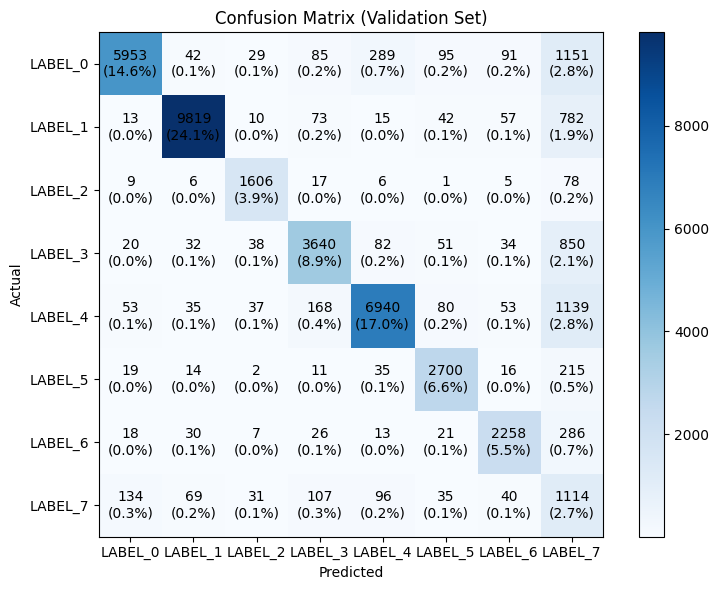

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Use labels directly from your StringIndexerModel
class_labels = label_indexer.labels  

# --- Collect predictions into Pandas
val_results = val_predictions.select("label_indexed", "final_prediction").toPandas()
y_true = val_results["label_indexed"].astype(int).values
y_pred = val_results["final_prediction"].astype(int).values

# --- Classification Report with your fixed labels
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# --- Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

# --- Add annotations: count + percentage (global)
cm_sum = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm[i, j] / cm_sum * 100
        ax.text(j, i, f"{count}\n({percent:.1f}%)",
                ha="center", va="center", color="black")

# --- Axis setup with fixed labels
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


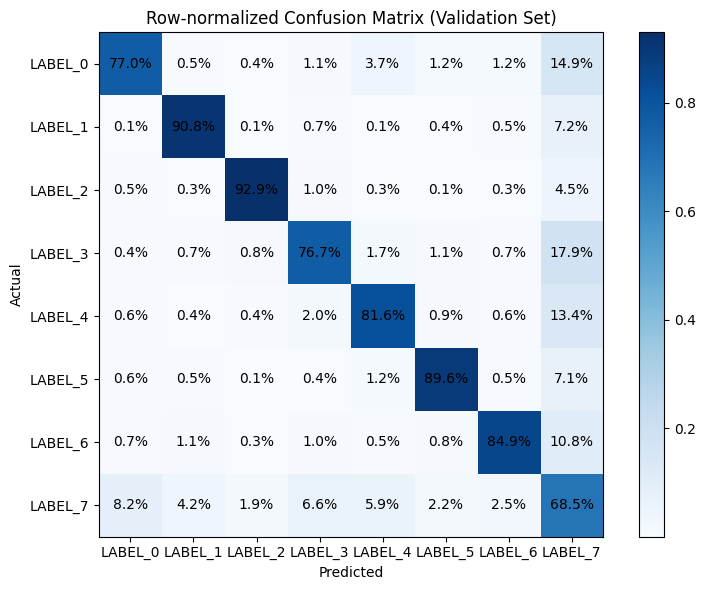

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- Confusion Matrix (row-normalized)
cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

# --- Annotate with % values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]*100:.1f}%",
                ha="center", va="center", color="black")

# --- Axis setup with fixed labels
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Row-normalized Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


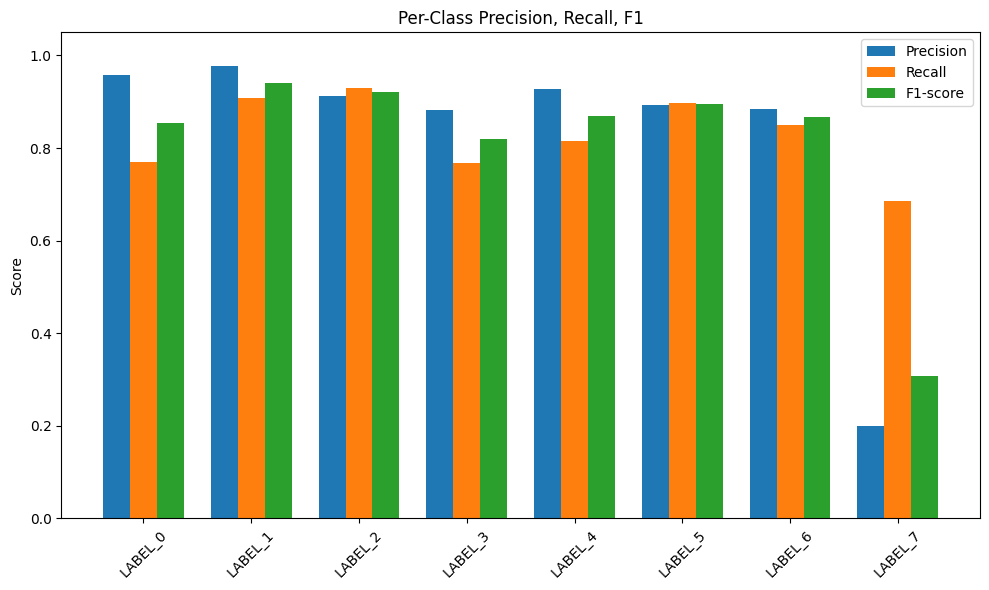

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# --- Calculate per-class metrics
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(len(class_labels)))

x = np.arange(len(class_labels))  # class positions

plt.figure(figsize=(10,6))
plt.bar(x - 0.25, prec, width=0.25, label="Precision")
plt.bar(x, rec, width=0.25, label="Recall")
plt.bar(x + 0.25, f1, width=0.25, label="F1-score")

plt.xticks(x, class_labels, rotation=45)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Per-Class Precision, Recall, F1")
plt.legend()
plt.tight_layout()
plt.show()


### SparkNLP LegalBERT Classifier Pipeline

In [26]:
from sparknlp.base import DocumentAssembler, EmbeddingsFinisher
from sparknlp.annotator import Tokenizer, BertEmbeddings, SentenceEmbeddings, ClassifierDLApproach
from pyspark.ml import Pipeline

# --- Step 1: Document + Tokenization
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# --- Step 2: Token-level LegalBERT embeddings
bert_embeddings = BertEmbeddings.load(
    "models/legal_bert_base_uncased_en_5.5.1_3.0_1738310564052"
).setInputCols(["document", "token"]) \
 .setOutputCol("bert_embeddings") \
 .setCaseSensitive(False)

# --- Step 3: Sentence embeddings (averaging)
sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "bert_embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

# --- Step 4: ClassifierDLApproach
classifier = ClassifierDLApproach() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCol("class") \
    .setLabelColumn("type_label") \
    .setBatchSize(32) \
    .setMaxEpochs(25) \
    .setLr(1e-4) \
    .setDropout(0.2) \
    .setEnableOutputLogs(True)

# --- Step 5: Build the NLP pipeline
nlp_pipeline = Pipeline(stages=[
    document,
    tokenizer,
    bert_embeddings,
    sentence_embeddings,
    classifier
])


Using CPUs


## ML FLOW - LEGALBERT + CLASSIFIERDL

In [ ]:
import mlflow
import mlflow.spark
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def run_experiment_legalbert_classifierdl(train_df, val_df, run_name="LegalBERT+ClassifierDL"):
    """
    Train and evaluate LegalBERT + ClassifierDLApproach with MLflow tracking.
    """

    with mlflow.start_run(run_name=run_name):

        # -----------------------------
        # Train Spark NLP pipeline
        # -----------------------------
        nlp_model = nlp_pipeline.fit(train_df)
        mlflow.spark.log_model(nlp_model, artifact_path="legalbert_classifierdl_model")

        # -----------------------------
        # Validation predictions
        # -----------------------------
        val_predictions = nlp_model.transform(val_df)

        # Convert Spark DF to pandas
        y_true = val_predictions.select("type_label").toPandas()["type_label"]
        y_pred = val_predictions.select("class.result").toPandas()["result"].apply(lambda x: x[0])

        # -----------------------------
        # Metrics
        # -----------------------------
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        report = classification_report(y_true, y_pred, output_dict=True)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_weighted", f1)

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report_classifierdl.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Save as CSV
        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix_classifierdl.csv"
        cm_df.to_csv(cm_csv_path, index=False)
        mlflow.log_artifact(cm_csv_path, artifact_path="evaluation")

        # Save as heatmap image
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix (LegalBERT + ClassifierDL)")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        cm_png_path = "confusion_matrix_classifierdl.png"
        plt.savefig(cm_png_path)
        plt.close()
        mlflow.log_artifact(cm_png_path, artifact_path="evaluation")

        print(f" Logged {run_name} with F1={f1:.4f}, Acc={acc:.4f}")


In [28]:
run_experiment_legalbert_classifierdl(train_df, val_df)


25/09/04 15:04:29 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:42:01 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/09/04 15:42:01 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/09/04 15:42:02 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
2025-09-04 16:25:34.500297: I external/org_tensorflow/tensorflow/cc/saved_model/reader.cc:43] Reading SavedModel from: /var/folders/6q/bqk5wgh97kx17wtj7dl1l3zw0000gn/T/b3608b383afa_classifier_dl784268613567356991
2025-09-04 16:25:34.550308: I external/org_tensorflow/tensorflow/cc/saved_model/reader.cc:107] Reading meta graph with tags { serve }
2025-09-04 16:25:34.550335: I external/org_tensorflow/tensorflow/cc/saved_model/reader.cc:148] Reading SavedModel debug info (if present) from: /var/folders/6q/bqk5wgh97kx17wtj7dl1l3zw0000gn/T/b3608b383afa_classifier_dl784268613567356991
2025-09-04 16:25:34.797532: I external/org_tensorflow/tensorflow/cc/sav

Training started - epochs: 25 - learning_rate: 1.0E-4 - batch_size: 32 - training_examples: 191668 - classes: 8
Epoch 1/25 - 22.38s - loss: 10244.81 - acc: 0.5777112 - batches: 5990
Epoch 2/25 - 21.05s - loss: 9868.635 - acc: 0.6386229 - batches: 5990
Epoch 3/25 - 21.73s - loss: 9667.441 - acc: 0.66986763 - batches: 5990
Epoch 4/25 - 20.82s - loss: 9593.085 - acc: 0.6796095 - batches: 5990
Epoch 5/25 - 21.24s - loss: 9561.292 - acc: 0.68353856 - batches: 5990
Epoch 6/25 - 21.42s - loss: 9545.5 - acc: 0.6855631 - batches: 5990
Epoch 7/25 - 21.29s - loss: 9534.725 - acc: 0.6873007 - batches: 5990
Epoch 8/25 - 20.58s - loss: 9526.397 - acc: 0.6885686 - batches: 5990
Epoch 9/25 - 20.63s - loss: 9519.604 - acc: 0.6896435 - batches: 5990
Epoch 10/25 - 20.54s - loss: 9514.02 - acc: 0.690494 - batches: 5990
Epoch 11/25 - 20.79s - loss: 9509.325 - acc: 0.6912715 - batches: 5990
Epoch 12/25 - 21.39s - loss: 9505.358 - acc: 0.69186634 - batches: 5990
Epoch 13/25 - 20.93s - loss: 9501.745 - acc: 0

2025/09/04 16:34:46 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/6q/bqk5wgh97kx17wtj7dl1l3zw0000gn/T/tmp_mg2vx8c/model, flavor: spark). Fall back to return ['pyspark==3.5.6']. Set logging level to DEBUG to see the full traceback. 
2025/09/04 16:34:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
25/09/04 16:34:47 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/09/04 16:44:05 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

✅ Logged LegalBERT+ClassifierDL with F1=0.6107, Acc=0.6946


/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**PERFROMANCE ANALYSIS - LEGALBERT + CLASSIFIERDL**

In [29]:
# Convert to pandas with the fallback column
val_results = val_predictions.select("type_label", "final_prediction").toPandas()

y_true = val_results["type_label"]
y_pred = val_results["final_prediction"]

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Classification report
print(classification_report(y_true, y_pred, digits=4))

# --- Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=val_results["type_label"].unique())
cmn = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(
    cmn, annot=True, fmt=".2f",
    xticklabels=val_results["type_label"].unique(),
    yticklabels=val_results["type_label"].unique(),
    cmap="Blues"
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Validation Set with Fallback)")
plt.show()


25/09/04 16:53:11 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


ValueError: Mix of label input types (string and number)

## LEGALBERT + LogisticRegression

In [30]:
from sparknlp.base import DocumentAssembler, EmbeddingsFinisher
from sparknlp.annotator import Tokenizer, BertEmbeddings, SentenceEmbeddings
from pyspark.ml import Pipeline
from pyspark.sql.functions import udf, col
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import LogisticRegression

# Step 1. NLP pipeline
# ------------------------
document = DocumentAssembler() \
    .setInputCol("description") \
    .setOutputCol("document")

tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# Load pretrained LegalBERT (local)
bert_embeddings = BertEmbeddings.load("models/legal_bert_base_uncased_en_5.5.1_3.0_1738310564052") \
    .setInputCols(["document", "token"]) \
    .setOutputCol("bert_embeddings") \
    .setCaseSensitive(False)

sentence_embeddings = SentenceEmbeddings() \
    .setInputCols(["document", "bert_embeddings"]) \
    .setOutputCol("sentence_embeddings") \
    .setPoolingStrategy("AVERAGE")

# Finish embeddings into Spark ML compatible array<float>
embeddings_finisher = EmbeddingsFinisher() \
    .setInputCols(["sentence_embeddings"]) \
    .setOutputCols(["raw_embeddings"]) \
    .setOutputAsVector(False) \
    .setCleanAnnotations(True)

# NLP pipeline (up to embeddings)
nlp_pipeline = Pipeline(stages=[
    document,
    tokenizer,
    bert_embeddings,
    sentence_embeddings,
    embeddings_finisher
])


# Step 2. Helper UDF: Array<float> -> VectorUDT
# ------------------------
to_vector = udf(lambda arr: Vectors.dense(arr), VectorUDT())

def add_features_column(df):
    # raw_embeddings is array<array<float>> → take first element
    return df.withColumn("features", to_vector(col("raw_embeddings")[0]))


# Step 3. Train Logistic Regression
# ------------------------
# Fit embeddings pipeline on train
nlp_model = nlp_pipeline.fit(train_df)
train_emb = nlp_model.transform(train_df)

# Convert to features + encode labels
train_ready = add_features_column(train_emb)
label_indexer = StringIndexer(inputCol="type_label", outputCol="label_index")
train_ready = label_indexer.fit(train_ready).transform(train_ready)

# Logistic regression classifier
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label_index",
     weightCol="class_weight",
    maxIter=180,
    regParam=0.1,
    elasticNetParam=0.1
)

lr_model = lr.fit(train_ready)

#  Validation
val_emb = nlp_model.transform(val_df)
val_ready = add_features_column(val_emb)
val_ready = label_indexer.fit(val_ready).transform(val_ready)

preds = lr_model.transform(val_ready)


Using CPUs


25/09/04 16:55:13 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
ERROR:root:KeyboardInterrupt while sending command.                (0 + 8) / 15]
Traceback (most recent call last):
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/Users/jefferyjapheth/miniconda3/envs/sparknlp/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
import mlflow
import mlflow.spark
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def run_experiment_legalbert_lr(
    train_df,
    val_df,
    run_name="LegalBERT+LogisticRegression"
):
    with mlflow.start_run(run_name=run_name):
        # -----------------------------
        # Fit embeddings pipeline
        # -----------------------------
        nlp_model = nlp_pipeline.fit(train_df)
        mlflow.spark.log_model(nlp_model, artifact_path="legalbert_pipeline_model")

        train_emb = nlp_model.transform(train_df)
        train_ready = add_features_column(train_emb)
        label_indexer_fit = StringIndexer(inputCol="type_label", outputCol="label_index")
        train_ready = label_indexer_fit.fit(train_ready).transform(train_ready)

        # -----------------------------
        # Logistic Regression
        # -----------------------------
        lr = LogisticRegression(
            featuresCol="features",
            labelCol="label_index",
            weightCol="class_weight",
            maxIter=180,
            regParam=0.1,
            elasticNetParam=0.1
        )
        lr_model = lr.fit(train_ready)
        mlflow.spark.log_model(lr_model, artifact_path="lr_model")

        # -----------------------------
        # Validation predictions
        # -----------------------------
        val_emb = nlp_model.transform(val_df)
        val_ready = add_features_column(val_emb)
        val_ready = label_indexer_fit.transform(val_ready)

        preds = lr_model.transform(val_ready)
        y_true = preds.select("label_index").toPandas()["label_index"]
        y_pred = preds.select("prediction").toPandas()["prediction"]

        # -----------------------------
        # Metrics
        # -----------------------------
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="weighted")
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_weighted", f1)

        # Save classification report
        report_df = pd.DataFrame(report).transpose()
        report_path = "classification_report.csv"
        report_df.to_csv(report_path, index=True)
        mlflow.log_artifact(report_path, artifact_path="evaluation")

        # Confusion matrix (CSV + PNG)
        cm = confusion_matrix(y_true, y_pred)
        cm_df = pd.DataFrame(cm)
        cm_csv_path = "confusion_matrix.csv"
        cm_df.to_csv(cm_csv_path, index=False)
        mlflow.log_artifact(cm_csv_path, artifact_path="evaluation")

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        cm_png_path = "confusion_matrix.png"
        plt.savefig(cm_png_path)
        plt.close()
        mlflow.log_artifact(cm_png_path, artifact_path="evaluation")

        print(f" Logged {run_name} with F1={f1:.4f}, Acc={acc:.4f}")


**PERFROMANCE ANALYSIS - LEGALBERT + LOGISTIC REGRESSION**

In [ ]:
# Fit StringIndexer only once on train (make sure outputCol doesn't exist yet)
label_indexer_model = StringIndexer(inputCol="type_label", outputCol="label_index_temp").fit(train_ready)

# Transform train and validation sets using this fitted model
train_ready = label_indexer_model.transform(train_ready)
val_ready = label_indexer_model.transform(val_ready)

# Extract class labels
class_labels = label_indexer_model.labels  # this is the list of string labels in order of index

# Collect predictions to Pandas
preds_pd = preds.select("label_index", "final_prediction").toPandas()
y_true = preds_pd["label_index"].astype(int).values
y_pred = preds_pd["final_prediction"].astype(int).values

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

cm_sum = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = count / cm_sum * 100
        ax.text(j, i, f"{count}\n({percent:.1f}%)", ha="center", va="center", color="black")

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Validation Set)")

plt.colorbar(im)
plt.tight_layout()
plt.show()


In [ ]:
# Per-class Precision / Recall / F1 bar chart
prec, rec, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(len(class_labels)))
x = np.arange(len(class_labels))

plt.figure(figsize=(10,6))
plt.bar(x - 0.25, prec, width=0.25, label="Precision")
plt.bar(x, rec, width=0.25, label="Recall")
plt.bar(x + 0.25, f1, width=0.25, label="F1-score")

plt.xticks(x, class_labels, rotation=45)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Per-Class Precision, Recall, F1")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
spark.stop()